In [365]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [294]:
df = pd.read_csv('../dataset/raw/house_price_bd.csv')

df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_15128\526258664.py:1: DtypeWarning: Columns (0: image_url) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../dataset/raw/house_price_bd.csv')


,area,building_type,building_nature,image_url,num_bath_rooms,num_bed_rooms,price,property_description,property_overview,property_url,...,id,relaxation_amenity_count,security_amenity_count,maintenance_or_cleaning_amenity_count,social_amenity_count,expendable_amenity_count,service_staff_amenity_count,unclassify_amenity_count,division,zone
0,1185.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,0.0,3.0,6100000.0,Grab This 1185 Sq Ft Beautiful Flat Is Vacant ...,This flat consists of facilities you can think...,https://www.bproperty.com/en/property/details-...,...,bproperty-0,0,1,2,0,2,0,3,Dhaka,Khilgaon
1,2464.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,4.0,3.0,28900000.0,A Vibrant 2464 Sq Ft Residential Flat For Sale...,Ready to move in somewhere with everything nea...,https://www.bproperty.com/en/property/details-...,...,bproperty-1,0,2,0,0,3,0,4,Dhaka,Dhanmondi
2,1140.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,0.0,3.0,7500000.0,1140 Sq Ft Nicely Planned Apartment Is Availab...,A spacious 1140 Square Feet apartment in Mirp...,https://www.bproperty.com/en/property/details-...,...,bproperty-2,0,2,2,0,2,0,4,Dhaka,Mirpur
3,1920.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,3.0,3.0,20000000.0,A Modern Well-planned Apartment Of 1920 Sq Ft ...,Looking for the perfect home that offers a lux...,https://www.bproperty.com/en/property/details-...,...,bproperty-3,0,1,2,0,3,0,3,Dhaka,Bashundhara R/A
4,1445.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,3.0,3.0,10800000.0,"1445 Sq Ft Ready Flat For Sale In Banasree, Wi...",Choosing a new home can be an overwhelming exp...,https://www.bproperty.com/en/property/details-...,...,bproperty-4,0,0,2,0,1,0,4,Dhaka,Khilgaon


In [295]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33701 entries, 0 to 33700
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   area                                   33701 non-null  float64
 1   building_type                          33701 non-null  str    
 2   building_nature                        33701 non-null  str    
 3   image_url                              17265 non-null  str    
 4   num_bath_rooms                         33701 non-null  float64
 5   num_bed_rooms                          33701 non-null  float64
 6   price                                  33701 non-null  float64
 7   property_description                   19029 non-null  str    
 8   property_overview                      18509 non-null  str    
 9   property_url                           33679 non-null  str    
 10  purpose                                33701 non-null  str    
 11  city         

In [296]:
df.shape

(33701, 24)

This dataset contains 33,701 rows and 24 columns. It includes a mix of data types: 4 numeric (float) columns, 7 numeric (integer) columns, and 13 text (categorical) columns. The dataset has some missing values, which will need to be checked and handled during the data cleaning step before further analysis.

In [297]:
df.describe()

,area,num_bath_rooms,num_bed_rooms,price,relaxation_amenity_count,security_amenity_count,maintenance_or_cleaning_amenity_count,social_amenity_count,expendable_amenity_count,service_staff_amenity_count,unclassify_amenity_count
count,3.370100e+04,33701.000000,33701.000000,3.370100e+04,33701.000000,33701.000000,33701.000000,33701.000000,33701.000000,33701.000000,33701.000000
mean,3.249107e+03,1.680870,2.318091,1.070405e+09,0.013887,0.496454,0.780570,0.080324,1.189015,0.021275,1.810747
std,1.220057e+05,1.635645,1.837590,1.318148e+11,0.188190,0.747793,1.009691,0.403382,1.552733,0.234156,2.122586
min,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000e+03,0.000000,2.000000,2.500000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.350000e+03,2.000000,3.000000,1.700000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,2.061000e+03,3.000000,3.000000,6.000000e+06,0.000000,1.000000,2.000000,0.000000,2.000000,0.000000,3.000000
max,1.450147e+07,50.000000,94.000000,2.400000e+13,5.000000,5.000000,3.000000,5.000000,6.000000,4.000000,18.000000


- area = 	Ranges from 0 to ~14.5 million. The huge gap between the 75th percentile (2,061) and max (14.5M) suggests outliers or data entry errors.
- price = 	Ranges from 0 to ~2.4 × 10¹³ (24 trillion). This is extremely unrealistic for a property price and strongly suggests incorrect or corrupted values.
- num_bed_rooms = Max value is 94, while 75% of values are 3 or less. This is likely an outlier or data entry mistake.
- num_bath_rooms = Max value is 50, while most values are between 0–3. Also likely to contain outliers.
- amenity columns (relaxation, security, cleaning, social, etc.) = Mostly low values (median = 0 for several), meaning many listings have few or no amenities. Distribution is right-skewed.
- Standard deviation vs mean = For several columns (area, price, bed/bath rooms), the standard deviation is much larger than the mean — a strong sign of skewed data and extreme outliers.

In [298]:
df.duplicated().sum()

np.int64(0)

There are no duplicate value

In [299]:
df.isna().sum()

area                                         0
building_type                                0
building_nature                              0
image_url                                16436
num_bath_rooms                               0
num_bed_rooms                                0
price                                        0
property_description                     14672
property_overview                        15192
property_url                                22
purpose                                      0
city                                         0
locality                                     0
address                                   5177
id                                           0
relaxation_amenity_count                     0
security_amenity_count                       0
maintenance_or_cleaning_amenity_count        0
social_amenity_count                         0
expendable_amenity_count                     0
service_staff_amenity_count                  0
unclassify_am

Three columns — image_url, property_overview, and property_description — are missing almost half their data. These are likely optional fields that not all listings filled in. Columns like address, zone, division, and property_url have only a small number of missing values and are easier to handle.

In [300]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))


--- area ---
area
1200.0    1327
0.0       1001
1500.0     928
800.0      927
1000.0     912
1100.0     897
1300.0     850
1250.0     820
2200.0     774
1400.0     741
900.0      641
700.0      600
2000.0     594
1350.0     576
1600.0     558
1150.0     553
1800.0     485
3000.0     481
1050.0     461
600.0      453
Name: count, dtype: int64

--- building_type ---
building_type
Apartment           26940
Office               2266
Building             1412
Shop                  956
Floor                 880
Residential Plot      875
House                 175
Duplex                 84
Commercial Plot        54
Warehouse              29
Factory                19
Others                 11
Name: count, dtype: int64

--- building_nature ---
building_nature
Residential    27220
Commercial      6481
Name: count, dtype: int64

--- image_url ---
image_url
NaN                                                                 16436
https://images-cdn.bproperty.com/thumbnails/1579849-800x600.jpeg    

In [301]:
sale_df = df[df['purpose'] == 'Sale'].copy()

print("Original dataset shape:", df.shape)
print("Sale dataset shape:", sale_df.shape)

print("\nPurpose distribution:")
print(df["purpose"].value_counts())

print("\nSale dataset preview:")
display(sale_df.head())

Original dataset shape: (33701, 24)
Sale dataset shape: (12978, 24)

Purpose distribution:
purpose
Rent    20723
Sale    12978
Name: count, dtype: int64

Sale dataset preview:


,area,building_type,building_nature,image_url,num_bath_rooms,num_bed_rooms,price,property_description,property_overview,property_url,...,id,relaxation_amenity_count,security_amenity_count,maintenance_or_cleaning_amenity_count,social_amenity_count,expendable_amenity_count,service_staff_amenity_count,unclassify_amenity_count,division,zone
0,1185.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,0.0,3.0,6100000.0,Grab This 1185 Sq Ft Beautiful Flat Is Vacant ...,This flat consists of facilities you can think...,https://www.bproperty.com/en/property/details-...,...,bproperty-0,0,1,2,0,2,0,3,Dhaka,Khilgaon
1,2464.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,4.0,3.0,28900000.0,A Vibrant 2464 Sq Ft Residential Flat For Sale...,Ready to move in somewhere with everything nea...,https://www.bproperty.com/en/property/details-...,...,bproperty-1,0,2,0,0,3,0,4,Dhaka,Dhanmondi
2,1140.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,0.0,3.0,7500000.0,1140 Sq Ft Nicely Planned Apartment Is Availab...,A spacious 1140 Square Feet apartment in Mirp...,https://www.bproperty.com/en/property/details-...,...,bproperty-2,0,2,2,0,2,0,4,Dhaka,Mirpur
3,1920.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,3.0,3.0,20000000.0,A Modern Well-planned Apartment Of 1920 Sq Ft ...,Looking for the perfect home that offers a lux...,https://www.bproperty.com/en/property/details-...,...,bproperty-3,0,1,2,0,3,0,3,Dhaka,Bashundhara R/A
4,1445.0,Apartment,Residential,https://images-cdn.bproperty.com/thumbnails/15...,3.0,3.0,10800000.0,"1445 Sq Ft Ready Flat For Sale In Banasree, Wi...",Choosing a new home can be an overwhelming exp...,https://www.bproperty.com/en/property/details-...,...,bproperty-4,0,0,2,0,1,0,4,Dhaka,Khilgaon


Since the purpose column likely contains different categories (e.g., "Sale" and "Rent"), this step filters the dataset to keep only the rows where purpose == 'Sale'. This creates a separate dataset (sale_df) focused only on properties listed for sale.

##### Why this step matters:
Since price had unrealistic values earlier (like 24 trillion), it's a good idea to analyze Sale and Rent listings separately — because sale prices and rent prices usually follow very different ranges. Mixing them together could distort the analysis and make outliers harder to detect.

In [302]:
print("Sale dataset information:")
sale_df.info()

Sale dataset information:
<class 'pandas.DataFrame'>
Index: 12978 entries, 0 to 32321
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   area                                   12978 non-null  float64
 1   building_type                          12978 non-null  str    
 2   building_nature                        12978 non-null  str    
 3   image_url                              10910 non-null  str    
 4   num_bath_rooms                         12978 non-null  float64
 5   num_bed_rooms                          12978 non-null  float64
 6   price                                  12978 non-null  float64
 7   property_description                   10926 non-null  str    
 8   property_overview                      10916 non-null  str    
 9   property_url                           12956 non-null  str    
 10  purpose                                12978 non-null  str  

In [303]:
print("\nMissing values in Sale dataset:")
print(sale_df.isnull().sum().sort_values(ascending=False))


Missing values in Sale dataset:
address                                  2676
image_url                                2068
property_overview                        2062
property_description                     2052
zone                                       28
property_url                               22
division                                    2
building_type                               0
price                                       0
num_bed_rooms                               0
num_bath_rooms                              0
building_nature                             0
area                                        0
locality                                    0
city                                        0
purpose                                     0
relaxation_amenity_count                    0
id                                          0
security_amenity_count                      0
maintenance_or_cleaning_amenity_count       0
expendable_amenity_count                    0
s

The missing value pattern in the Sale dataset looks the same as the full dataset — mostly address, image_url, property_overview, and property_description have gaps, while important numeric columns like price and area are complete.

In [304]:
print("\nSale dataset descriptive statistics:")
display(sale_df.describe().T)


Sale dataset descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
area,12978.0,1.664862e+03,3.755222e+03,1.0,1090.0,1320.0,1685.0,2.966000e+05
num_bath_rooms,12978.0,1.483048e+00,1.620236e+00,0.0,0.0,2.0,3.0,1.600000e+01
num_bed_rooms,12978.0,2.688242e+00,2.222962e+00,0.0,2.0,3.0,3.0,9.400000e+01
price,12978.0,2.762862e+09,2.124047e+11,0.0,5000000.0,7350000.0,11500000.0,2.400000e+13
relaxation_amenity_count,12978.0,2.712282e-02,2.634167e-01,0.0,0.0,0.0,0.0,5.000000e+00
security_amenity_count,12978.0,7.237633e-01,7.614777e-01,0.0,0.0,1.0,1.0,3.000000e+00
maintenance_or_cleaning_amenity_count,12978.0,1.270612e+00,1.042726e+00,0.0,0.0,1.0,2.0,3.000000e+00
social_amenity_count,12978.0,1.319155e-01,5.418567e-01,0.0,0.0,0.0,0.0,5.000000e+00
expendable_amenity_count,12978.0,1.913007e+00,1.559505e+00,0.0,0.0,2.0,3.0,6.000000e+00
service_staff_amenity_count,12978.0,1.541070e-04,1.241350e-02,0.0,0.0,0.0,0.0,1.000000e+00


In [305]:
# Price distribution
print("Price quantiles:")
print(
    sale_df["price"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.0]
    )
)

Price quantiles:
0.00    0.000000e+00
0.01    1.700000e+06
0.05    3.000000e+06
0.25    5.000000e+06
0.50    7.350000e+06
0.75    1.150000e+07
0.90    2.100000e+07
0.95    3.800000e+07
0.99    5.423000e+09
1.00    2.400000e+13
Name: price, dtype: float64


Price look normal and reasonable up to the 95th percentile. But after that massive price jump found which is not normal.

In [306]:
print("Number of zero-price properties:")
print((sale_df["price"] == 0).sum())

print("\nProperties with price below 1,000,000:")
print((sale_df["price"] < 1_000_000).sum())

print("\nProperties above 100 million:")
print((sale_df["price"] > 100_000_000).sum())

Number of zero-price properties:
2

Properties with price below 1,000,000:
42

Properties above 100 million:
279


In [307]:
extreme_price = sale_df[
    (sale_df["price"] == 0) |
    (sale_df["price"] > 100_000_000)
][[
    "area",
    "building_type",
    "building_nature",
    "num_bath_rooms",
    "num_bed_rooms",
    "price",
    "city",
    "locality",
    "zone"
]]

display(
    extreme_price.sort_values("price")
)

,area,building_type,building_nature,num_bath_rooms,num_bed_rooms,price,city,locality,zone
32175,3756.0,Office,Commercial,0.0,0.0,0.000000e+00,Dhaka,Mohammadpur,Mohammadpur
32071,1150.0,Apartment,Residential,2.0,3.0,0.000000e+00,Dhaka,Agargaon,Sher-E-Bangla Nagar
20852,5365.0,Apartment,Residential,5.0,4.0,1.019350e+08,Dhaka,Gulshan 2,Gulshan
21733,3685.0,Apartment,Residential,5.0,4.0,1.031800e+08,Dhaka,Baridhara,Gulshan
10499,3000.0,Office,Commercial,0.0,0.0,1.050000e+08,Dhaka,Banani,Banani
...,...,...,...,...,...,...,...,...,...
22459,6550.0,Apartment,Residential,6.0,5.0,7.205000e+11,Dhaka,Gulshan 1,Gulshan
22586,12000.0,House,Residential,7.0,10.0,1.080000e+12,Dhaka,Uttara West,Uttara
22723,15000.0,House,Residential,4.0,4.0,1.200000e+12,Dhaka,Rampura,Khilgaon
22722,9000.0,House,Residential,4.0,4.0,2.250000e+12,Dhaka,Banani,Banani


##### Pattern 1: Price = 0 (Invalid)

- Some rows show price = 0, which doesn't make sense for a property listed for sale. For example, rows 32175 and 32071 have valid area, bedroom, and bathroom values, but zero price — this is likely missing data recorded as 0, rather than a genuinely free property.

##### Pattern 2: Extremely High Prices (Billions/Trillions)

- Most locations here (Gulshan, Banani, Uttara) are known as premium, high-value areas in Dhaka, so higher prices are somewhat expected. However, values like 720 billion, 1.08 trillion, 2.25 trillion, and 24 trillion are far beyond realistic property prices, even for premium locations. For example, row 23348 shows a price of 24 trillion for a 10,000 sq ft apartment — this is almost certainly a data entry error, likely from extra zeros being added by mistake.

In [308]:
print("Area quantiles:")
print(
    sale_df["area"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.0]
    )
)

Area quantiles:
0.00         1.000
0.01       115.000
0.05       650.000
0.25      1090.000
0.50      1320.000
0.75      1685.000
0.90      2289.300
0.95      3600.000
0.99      7218.216
1.00    296600.000
Name: area, dtype: float64


Area values look reasonable up to the 99th percentile (max ~7,218). But the very last 1% jumps drastically to 296,600, which is far too large to be realistic for most residential properties. This confirms the same pattern seen in price — a small number of extreme outliers or data entry errors in the top 1% of the data.

The minimum value of 1 is also suspicious, since a property with an area of 1 (likely sq. ft.) is not realistic either.

In [309]:
print("Properties with area <= 100 sq ft:")
print((sale_df['area'] <= 100).sum())

print("\nProperties with area > 10,000 sq ft:")
print((sale_df["area"] > 10_000).sum())

Properties with area <= 100 sq ft:
69

Properties with area > 10,000 sq ft:
78


In [310]:
extreme_area = sale_df[
    (sale_df["area"] <= 100) |
    (sale_df["area"] > 10_000)
][[
    "area",
    "building_type",
    "building_nature",
    "price",
    "num_bath_rooms",
    "num_bed_rooms",
    "city",
    "locality",
    "zone"
]]

display(extreme_area.sort_values("area"))

,area,building_type,building_nature,price,num_bath_rooms,num_bed_rooms,city,locality,zone
22583,1.0,House,Residential,6.000000e+06,1.0,8.0,Narayanganj,Narayanganj,Sub-district of Narayanganj
21847,1.0,Apartment,Residential,1.400000e+08,3.0,4.0,Dhaka,Bashundhara RA,Bashundhara R/A
22907,1.0,Apartment,Residential,5.000000e+03,4.0,3.0,Dhaka,Savar,Savar
22778,1.0,House,Residential,2.500000e+05,3.0,3.0,Moulvibazar,Moulvibazar Sadar,Sub-district of Moulvibazar
23060,1.0,Apartment,Residential,1.200000e+04,3.0,3.0,Dhaka,Ramna,Ramna
...,...,...,...,...,...,...,...,...,...
10815,80000.0,Building,Commercial,1.080000e+09,0.0,0.0,Dhaka,Uttara,Uttara
8281,90720.0,Residential Plot,Residential,1.352000e+08,0.0,0.0,Dhaka,Savar,Savar
4680,118080.0,Residential Plot,Residential,2.720000e+08,0.0,0.0,Gazipur,Gazipur Sadar Upazila,Sub-district of Gazipur
9061,174240.0,Residential Plot,Residential,1.200000e+08,0.0,0.0,Gazipur,Gazipur Sadar Upazila,Sub-district of Gazipur


##### Pattern 1: Area = 1 (Too Small)

- Several rows show area = 1, which is unrealistic for any property — houses, apartments, etc. For example, row 21847 shows area = 1 but a price of 140 million, and row 22907 shows area = 1 with a price of only 5,000. These mismatched values confirm that area = 1 is invalid data, likely caused by a missing or default value entered during data collection, rather than an actual property size.

##### Pattern 2: Very Large Areas (Mostly "Residential Plot" Type)

- Most of the largest area values (80,000 to 296,600) belong to building_type = "Residential Plot" or "Building". This makes sense in one way — land plots are typically much bigger than a house or apartment unit — but it's worth checking if these areas are measured in a different unit (e.g., total land size vs. built-up area), since mixing plot sizes with house/apartment sizes in the same column could distort analysis.

One exception stands out: row 21985 shows building_type = "Apartment" with an area of 296,600 — this is very unlikely for a single apartment and is almost certainly a data entry error.

In [311]:
print("Bedroom distribution:")
print(sale_df['num_bed_rooms'].value_counts().sort_index())

print("\nBathroom  distribution:")
print(sale_df['num_bath_rooms'].value_counts().sort_index())

Bedroom distribution:
num_bed_rooms
0.0     1632
1.0       29
2.0     1857
3.0     8285
4.0      977
5.0       59
6.0       31
7.0       29
8.0        8
9.0        1
10.0       6
11.0       2
12.0      10
13.0       2
14.0       4
15.0       2
16.0       4
17.0       2
18.0       7
19.0       2
20.0       1
21.0       3
22.0       1
23.0       1
24.0       6
25.0       2
29.0       1
30.0       1
32.0       1
33.0       1
36.0       1
40.0       1
42.0       1
46.0       1
48.0       1
50.0       1
56.0       2
60.0       1
75.0       1
94.0       1
Name: count, dtype: int64

Bathroom  distribution:
num_bath_rooms
0.0     6442
1.0       44
2.0     1832
3.0     3582
4.0      855
5.0      140
6.0       32
7.0        5
8.0       12
9.0        3
10.0      27
12.0       2
13.0       1
16.0       1
Name: count, dtype: int64


- Beyond that, values become extremely rare and unrealistic — for example, 94, 75, 60, 56 bedrooms, each appearing only 1–2 times. These are almost certainly outliers or data entry errors, since a normal residential property wouldn't realistically have this many bedrooms.

- Similar to bedrooms, a small number of listings show unrealistic values like 16, 13, 12, or 10 bathrooms, which are likely data entry errors.

In [312]:
display(
    sale_df[
        (sale_df["num_bed_rooms"] > 10) |
        (sale_df["num_bath_rooms"] > 10)
    ][[
        "area",
        "building_type",
        "building_nature",
        "num_bed_rooms",
        "num_bath_rooms",
        "price",
        "city",
        "locality",
        "zone"
    ]].sort_values("num_bed_rooms", ascending=False)
)

,area,building_type,building_nature,num_bed_rooms,num_bath_rooms,price,city,locality,zone
8324,21780.0,Building,Residential,94.0,0.0,3.700000e+07,Chattogram,Halishahar,Chattogram City
4142,21600.0,Building,Residential,75.0,0.0,4.000000e+07,Dhaka,Savar,Savar
1904,23000.0,Building,Residential,60.0,0.0,1.500000e+08,Dhaka,Mirpur,Mirpur
9830,30000.0,Building,Residential,56.0,0.0,3.500000e+08,Dhaka,Kathalbagan,Ramna
974,20685.0,Building,Residential,56.0,10.0,6.700000e+07,Dhaka,Dakshin Khan,Dakshin Khan
...,...,...,...,...,...,...,...,...,...
8136,3640.0,Building,Residential,12.0,10.0,1.200000e+08,Dhaka,Uttara,Uttara
22652,885.0,House,Residential,12.0,12.0,1.770000e+10,Dhaka,Tejgaon,Tejgaon
6891,3900.0,Building,Residential,11.0,6.0,2.500000e+07,Dhaka,Mirpur,Mirpur
9385,3600.0,Building,Residential,11.0,6.0,3.200000e+07,Dhaka,Savar,Savar


1. building_type = "Building" is involved in most extreme cases. Listings like 94, 75, 60, and 56 bedrooms are almost all labeled as "Building" rather than a typical house or apartment. This suggests these entries might actually represent an entire building with multiple units, not a single residential unit — and the bedroom/bathroom count may have been entered as a total across the whole building instead of per unit.
2. Price doesn't match the size in several cases. For example, row 22652 shows an area of just 885 with 12 bedrooms/12 bathrooms, but a price of 17.7 billion — this combination is highly unrealistic for a single property and strongly suggests a data entry error.
3. Some values may be swapped or misrecorded. Row 974 shows 56 bedrooms but only 0 bathrooms, and row 8136 shows 12 bedrooms with 10 bathrooms — an unusual ratio that hints at possible incorrect data entry rather than genuine property details.
4. Locations are spread across multiple cities (Dhaka, Chattogram, Tangail), so this isn't a location-specific issue — it looks like a broader data quality problem in how bedroom/bathroom counts were recorded for certain listings.

In [313]:
sale_df = sale_df[sale_df['price'] > 0].copy()

In [314]:
sale_df['price_per_sqft'] = (
    sale_df['price'] / sale_df['area']
)

In [315]:
low_price = sale_df[
    sale_df['price'] < 1_000_000
][[
    "area",
    "building_type",
    "building_nature",
    "num_bath_rooms",
    "num_bed_rooms",
    "price",
    "city",
    "locality",
    "zone"
]]

print("Number of properties below ৳1M:", len(low_price))

display(
    low_price.sort_values('price')
)

Number of properties below ৳1M: 40


,area,building_type,building_nature,num_bath_rooms,num_bed_rooms,price,city,locality,zone
17606,2400.0,Duplex,Residential,3.0,3.0,20.0,Dhaka,Adabor,Mohammadpur
17605,2200.0,Duplex,Residential,5.0,4.0,50.0,Dhaka,Bashundhara,Bashundhara R/A
22907,1.0,Apartment,Residential,4.0,3.0,5000.0,Dhaka,Savar,Savar
22651,6000.0,House,Residential,5.0,5.0,6000.0,Chattogram,Chattogram City,Chattogram City
23114,2.0,Apartment,Residential,2.0,2.0,10000.0,Dhaka,Mirpur,Mirpur
23060,1.0,Apartment,Residential,3.0,3.0,12000.0,Dhaka,Ramna,Ramna
21066,2.0,Apartment,Residential,1.0,3.0,12000.0,Dhaka,Uttara West,Uttara
22358,2.0,Apartment,Residential,3.0,3.0,13000.0,Bogura,Bogura Sadar,Sub-district of Bogura
23462,2.0,Apartment,Residential,3.0,3.0,13000.0,Dhaka,New Market,New Market
22918,4.0,Apartment,Residential,2.0,2.0,14000.0,Narayanganj,Narayanganj,Sub-district of Narayanganj


Only 40 properties (out of 12,978) have a price below ৳1,000,000, which is very low for real estate in Bangladesh. Looking closely, two clear patterns emerge:

##### Pattern 1: Unrealistically Low Prices for Apartments/Houses/Duplex

- Many listings with area between 1–2,400 sq ft (apartments, houses, duplexes) show prices as low as ৳20 to ৳25,650 — far too cheap for real properties. For example, a 2,400 sq ft duplex priced at just ৳20 is clearly a data entry error, likely missing several zeros or entered incorrectly.

##### Pattern 2: "Residential Plot" Listings

- A large portion of the low-price rows (14 out of 40) belong to building_type = "Residential Plot", with prices ranging from ৳140,000 to ৳975,000. These could potentially be legitimate low-cost land prices (e.g., undeveloped land in certain areas), but it's still worth double-checking since some plot sizes (2,160–3,600 sq ft) seem large for such a small price.

##### Pattern 3: Commercial Listings (Shop/Office/Floor)

- A few rows (Shop, Office, Floor) also show low prices (৳60,000–৳864,000), which may represent small commercial spaces or could be entry errors — harder to tell without more context.

In [316]:
small_area = sale_df[
    sale_df['area'] <= 100
][[
    "area",
    "building_type",
    "building_nature",
    "num_bath_rooms",
    "num_bed_rooms",
    "price",
    "city",
    "locality",
    "zone"
]]

print("Number of properties with area <= 100:", len(small_area))

display(
    small_area.sort_values("area")
)

Number of properties with area <= 100: 69


,area,building_type,building_nature,num_bath_rooms,num_bed_rooms,price,city,locality,zone
23060,1.0,Apartment,Residential,3.0,3.0,12000.0,Dhaka,Ramna,Ramna
22583,1.0,House,Residential,1.0,8.0,6000000.0,Narayanganj,Narayanganj,Sub-district of Narayanganj
22778,1.0,House,Residential,3.0,3.0,250000.0,Moulvibazar,Moulvibazar Sadar,Sub-district of Moulvibazar
21847,1.0,Apartment,Residential,3.0,4.0,140000000.0,Dhaka,Bashundhara RA,Bashundhara R/A
22907,1.0,Apartment,Residential,4.0,3.0,5000.0,Dhaka,Savar,Savar
...,...,...,...,...,...,...,...,...,...
10765,100.0,Shop,Commercial,0.0,0.0,3800000.0,Chattogram,31 No. Alkoron Ward,Chattogram City
10764,100.0,Shop,Commercial,0.0,0.0,3800000.0,Chattogram,31 No. Alkoron Ward,Chattogram City
10747,100.0,Shop,Commercial,0.0,0.0,1300000.0,Chattogram,22 No. Enayet Bazaar Ward,Chattogram City
10454,100.0,Shop,Commercial,0.0,0.0,3800000.0,Chattogram,31 No. Alkoron Ward,Chattogram City


This shows 69 properties with very small area values (as low as 1 sq ft, up to around 100 sq ft). Looking closely, two clear patterns emerge:

##### Pattern 1: Area = 1 (Clearly Invalid)

- Several rows show area = 1, paired with completely unrelated prices — ranging from ৳5,000 to ৳140,000,000. Since the area value doesn't change but the prices vary wildly, this confirms that area = 1 is a placeholder/default value, not a real measurement — likely entered when the actual area was missing or unknown.

##### Pattern 2: Small Commercial Shops (~100 sq ft)

- Many rows with area = 100 belong to building_type = "Shop" or "Others" (Commercial). These prices (৳1,300,000–৳3,800,000) actually look realistic for small retail shops or stalls, since small commercial units genuinely can be around 100 sq ft in size (e.g., a market stall). This pattern is different from the area = 1 issue — these look like valid data, not errors.

In [317]:
print("Price per square foot quantiles:")

print(
    sale_df['price_per_sqft'].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.99, 1.0]
    )
)

Price per square foot quantiles:
0.00    8.333333e-03
0.01    1.388889e+03
0.05    2.566389e+03
0.25    4.600000e+03
0.50    5.760000e+03
0.75    7.745726e+03
0.90    1.162617e+04
0.99    5.500000e+06
1.00    2.400000e+09
Name: price_per_sqft, dtype: float64


- This is one of the clearest signs of bad data so far. Between the 90th and 99th percentile, price per sqft jumps from ~11,626 to 5.5 million — and the very top value shoots up to 2.4 billion per sqft, which is impossible in real life. This confirms that the extreme price and area outliers found earlier are combining to create these unrealistic ratios.

- The minimum value (0.008) is also invalid — a property can't realistically sell for less than 1 taka per square foot.

In [318]:
display(
    sale_df.sort_values(
        'price_per_sqft',
        ascending=False
    )[[
        "area",
        "building_type",
        "building_nature",
        "price",
        "price_per_sqft",
        "num_bed_rooms",
        "num_bath_rooms",
        "city",
        "locality",
        "zone"
    ]].head(30)
)

,area,building_type,building_nature,price,price_per_sqft,num_bed_rooms,num_bath_rooms,city,locality,zone
23348,10000.0,Apartment,Residential,2.400000e+13,2.400000e+09,10.0,8.0,Dhaka,Moghbazar,Ramna
22722,9000.0,House,Residential,2.250000e+12,2.500000e+08,4.0,4.0,Dhaka,Banani,Banani
21847,1.0,Apartment,Residential,1.400000e+08,1.400000e+08,4.0,3.0,Dhaka,Bashundhara RA,Bashundhara R/A
22202,5250.0,Apartment,Residential,6.562500e+11,1.250000e+08,4.0,5.0,Dhaka,Baridhara,Gulshan
22459,6550.0,Apartment,Residential,7.205000e+11,1.100000e+08,5.0,6.0,Dhaka,Gulshan 1,Gulshan
22811,1750.0,House,Residential,1.750000e+11,1.000000e+08,2.0,2.0,Dhaka,Bashundhara RA,Bashundhara R/A
21845,4700.0,Apartment,Residential,4.700000e+11,1.000000e+08,5.0,5.0,Dhaka,Dhanmondi,Dhanmondi
21791,3685.0,Apartment,Residential,3.685000e+11,1.000000e+08,4.0,4.0,Dhaka,Baridhara,Gulshan
20818,3515.0,Apartment,Residential,3.163500e+11,9.000000e+07,4.0,4.0,Dhaka,Baridhara,Gulshan
22586,12000.0,House,Residential,1.080000e+12,9.000000e+07,10.0,7.0,Dhaka,Uttara West,Uttara


1. Almost all extreme rows come from realistic locations (Gulshan, Banani, Dhanmondi, Bashundhara, Uttara — premium Dhaka areas), which means the location and property type look genuine, but the price value itself is wrong. This strongly supports the theory of accidental extra zeros during data entry rather than fake/random listings.
2. The pattern looks systematic, not random. Many prices are suspiciously round multiples (e.g., 100 million, 90 million, 80 million per sqft), suggesting a consistent data entry mistake — possibly the actual price was multiplied by 1,000 or more, or an extra field got merged into the price column.
3. Row 23348 is the most extreme case — price of ৳24 trillion for a 10,000 sqft apartment in Moghbazar — this single row is likely the reason the earlier .describe() mean and std were so distorted.
4. A few rows also have small/invalid area values (row 21847 with area = 1, row 22679 with area = 2) combined with large prices, which inflates price_per_sqft from the area side instead of the price side — a double outlier case.

In [319]:
sale_clean = sale_df.copy()

print("Before cleaning:", sale_clean.shape)

Before cleaning: (12976, 25)


In [320]:
sale_clean = sale_clean[
    sale_clean["price"] > 0
].copy()

print("After removing invalid prices:", sale_clean.shape)

After removing invalid prices: (12976, 25)


In [321]:
sale_clean = sale_clean[
    sale_clean['area'] >= 100
].copy()

print("After removing impossible areas:", sale_clean.shape)

After removing impossible areas: (12919, 25)


In [322]:
print(
    sale_clean["price"].quantile(
        [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 1.0]
    )
)

0.900    2.100000e+07
0.950    3.800000e+07
0.970    6.000000e+07
0.980    1.118560e+08
0.990    5.482000e+09
0.995    1.728329e+10
0.999    1.658200e+11
1.000    2.400000e+13
Name: price, dtype: float64


This zoomed-in view pinpoints exactly where the data breaks down. Prices grow gradually and reasonably from 90% to 98% (21 million → 111 million) — this range still looks realistic for high-end properties. But right after the 98th percentile, prices explode — jumping from ~112 million to 5.48 billion at the 99th percentile, and continuing to spiral into billions and trillions after that.

This confirms that the cutoff point for genuine data is around the 98th percentile (~112 million). Anything beyond that — roughly the top 2% of listings — is very likely corrupted or contains data entry errors.

In [323]:
display(
    sale_clean.sort_values(
        "price",
        ascending=False
    )[[
        "area",
        "building_type",
        "building_nature",
        "price",
        "num_bed_rooms",
        "num_bath_rooms",
        "city",
        "locality",
        "zone"
    ]].head(50)
)

,area,building_type,building_nature,price,num_bed_rooms,num_bath_rooms,city,locality,zone
23348,10000.0,Apartment,Residential,2.400000e+13,10.0,8.0,Dhaka,Moghbazar,Ramna
22722,9000.0,House,Residential,2.250000e+12,4.0,4.0,Dhaka,Banani,Banani
22723,15000.0,House,Residential,1.200000e+12,4.0,4.0,Dhaka,Rampura,Khilgaon
22586,12000.0,House,Residential,1.080000e+12,10.0,7.0,Dhaka,Uttara West,Uttara
22459,6550.0,Apartment,Residential,7.205000e+11,5.0,6.0,Dhaka,Gulshan 1,Gulshan
22202,5250.0,Apartment,Residential,6.562500e+11,4.0,5.0,Dhaka,Baridhara,Gulshan
21845,4700.0,Apartment,Residential,4.700000e+11,5.0,5.0,Dhaka,Dhanmondi,Dhanmondi
21791,3685.0,Apartment,Residential,3.685000e+11,4.0,4.0,Dhaka,Baridhara,Gulshan
20818,3515.0,Apartment,Residential,3.163500e+11,4.0,4.0,Dhaka,Baridhara,Gulshan
22584,5400.0,House,Residential,3.024000e+11,2.0,3.0,Dhaka,Uttara East,Uttara


In [324]:
thresholds = [
    50_000_000,
    100_000_000,
    500_000_000,
    1_000_000_000,
    10_000_000_000,
    100_000_000_000
]

for threshold in thresholds:
    count = (sale_clean["price"] > threshold).sum()
    print(f"Price > ৳{threshold:,}: {count}")

Price > ৳50,000,000: 467
Price > ৳100,000,000: 277
Price > ৳500,000,000: 174
Price > ৳1,000,000,000: 167
Price > ৳10,000,000,000: 92
Price > ৳100,000,000,000: 23


In [325]:
extreme_price = sale_clean[
    sale_clean["price"] > 10_000_000_000
]

print("Extreme records:", len(extreme_price))

print("\nBuilding type:")
print(extreme_price["building_type"].value_counts())

print("\nBuilding nature:")
print(extreme_price["building_nature"].value_counts())

print("\nCity:")
print(extreme_price["city"].value_counts())

display(
    extreme_price[[
        "area",
        "building_type",
        "building_nature",
        "price",
        "num_bed_rooms",
        "num_bath_rooms",
        "city",
        "locality",
        "zone"
    ]].sort_values("price", ascending=False)
)

Extreme records: 92

Building type:
building_type
Apartment    69
House        23
Name: count, dtype: int64

Building nature:
building_nature
Residential    92
Name: count, dtype: int64

City:
city
Dhaka        80
Sylhet        3
Khulna        2
Rangpur       2
Rajshahi      2
Nawabganj     1
Barishal      1
Tangail       1
Name: count, dtype: int64


,area,building_type,building_nature,price,num_bed_rooms,num_bath_rooms,city,locality,zone
23348,10000.0,Apartment,Residential,2.400000e+13,10.0,8.0,Dhaka,Moghbazar,Ramna
22722,9000.0,House,Residential,2.250000e+12,4.0,4.0,Dhaka,Banani,Banani
22723,15000.0,House,Residential,1.200000e+12,4.0,4.0,Dhaka,Rampura,Khilgaon
22586,12000.0,House,Residential,1.080000e+12,10.0,7.0,Dhaka,Uttara West,Uttara
22459,6550.0,Apartment,Residential,7.205000e+11,5.0,6.0,Dhaka,Gulshan 1,Gulshan
...,...,...,...,...,...,...,...,...,...
22763,1420.0,Apartment,Residential,1.065000e+10,3.0,4.0,Dhaka,Pallabi,Mirpur
22002,1500.0,Apartment,Residential,1.050000e+10,3.0,3.0,Dhaka,Mirpur,Mirpur
22685,2300.0,House,Residential,1.035000e+10,3.0,1.0,Rangpur,Rangpur City,Sub-district of Rangpur
21880,1350.0,Apartment,Residential,1.012500e+10,3.0,3.0,Dhaka,Badda,Badda


The vast majority of extreme price records (80 out of 92, ~87%) are located in Dhaka, which makes sense since Dhaka is the most expensive real estate market in the dataset. However, even accounting for high demand in Dhaka, values in the billions and trillions are still unrealistic for residential apartments and houses — confirming these are data entry errors, not just "expensive but valid" listings.

In [326]:
print("Duplicate rows:", sale_clean.duplicated().sum())

Duplicate rows: 0


In [327]:
print("Duplicate IDs:", sale_clean["id"].duplicated().sum())

Duplicate IDs: 0


In [328]:
duplicate_ids = sale_clean[
    sale_clean["id"].duplicated(keep=False)
].sort_values("id")

display(
    duplicate_ids[[
        "id",
        "area",
        "building_type",
        "price",
        "city",
        "locality",
        "zone"
    ]]
)

,id,area,building_type,price,city,locality,zone


In [329]:
before = len(sale_clean)

sale_clean = sale_clean[
    sale_clean["price"] <= 10_000_000_000
].copy()

removed = before - len(sale_clean)

print("Removed extreme price records:", removed)
print("Remaining rows:", len(sale_clean))

Removed extreme price records: 92
Remaining rows: 12827


In [330]:
print("Final Sale dataset shape:", sale_clean.shape)

print("\nPrice statistics:")
display(sale_clean["price"].describe())

print("\nArea statistics:")
display(sale_clean["area"].describe())

print("\nRemaining zero/negative prices:")
print((sale_clean["price"] <= 0).sum())

print("\nRemaining area < 100:")
print((sale_clean["area"] < 100).sum())

print("\nRemaining price > ৳10B:")
print((sale_clean["price"] > 10_000_000_000).sum())

Final Sale dataset shape: (12827, 25)

Price statistics:


count    1.282700e+04
mean     4.377507e+07
std      4.564442e+08
min      2.000000e+01
25%      5.000000e+06
50%      7.300000e+06
75%      1.150000e+07
max      9.942500e+09
Name: price, dtype: float64


Area statistics:


count     12827.000000
mean       1663.552834
std        3767.336174
min         100.000000
25%        1095.500000
50%        1320.000000
75%        1680.000000
max      296600.000000
Name: area, dtype: float64


Remaining zero/negative prices:
0

Remaining area < 100:
0

Remaining price > ৳10B:
0


The cleaning step successfully removed the most extreme, clearly invalid records (like the ৳24 trillion listing). However, looking closely at the statistics, a few mild inconsistencies still remain:

- The minimum price (৳20) is still unrealistically low for a property.
- The maximum area (296,600 sqft) is still very large compared to the median (1,320 sqft) — likely a large land plot rather than a house/apartment.
- The standard deviation is still much bigger than the mean for both price and area, meaning some outliers are still present, just less extreme than before.

This is normal in real-world data cleaning — the goal usually isn't to remove every unusual value, but to remove the ones that are clearly impossible or would distort the analysis. The dataset is now in a much more usable state.

In [331]:
display(
    sale_clean[
        [
            "area",
            "building_type",
            "building_nature",
            "price",
            "num_bed_rooms",
            "num_bath_rooms",
            "city",
            "locality",
            "zone"
        ]
    ]
    .sort_values("price")
    .head(50)
)

,area,building_type,building_nature,price,num_bed_rooms,num_bath_rooms,city,locality,zone
17606,2400.0,Duplex,Residential,20.0,3.0,3.0,Dhaka,Adabor,Mohammadpur
17605,2200.0,Duplex,Residential,50.0,4.0,5.0,Dhaka,Bashundhara,Bashundhara R/A
22651,6000.0,House,Residential,6000.0,5.0,5.0,Chattogram,Chattogram City,Chattogram City
32239,1500.0,Office,Commercial,60000.0,0.0,0.0,Dhaka,Tejgaon,Tejgaon
32317,3600.0,Residential Plot,Residential,140000.0,0.0,0.0,Dhaka,Keraniganj,Keraniganj
32128,3600.0,Residential Plot,Residential,250000.0,0.0,0.0,Dhaka,Savar,Savar
10837,5000.0,Floor,Commercial,250000.0,0.0,0.0,Dhaka,Uttara,Uttara
22598,700.0,Apartment,Residential,273000.0,2.0,2.0,Dhaka,Khilkhet,Khilkhet
20737,2000.0,Apartment,Residential,350000.0,3.0,3.0,Dhaka,New Market,New Market
32133,720.0,Residential Plot,Residential,400000.0,0.0,0.0,Dhaka,Dakshin Khan,Dakshin Khan


In [332]:
print(
    sale_clean["price"].quantile(
        [0.001, 0.005, 0.01, 0.02, 0.05]
    )
)

0.001     741300.0
0.005    1406500.0
0.010    2000000.0
0.020    2400000.0
0.050    3006336.0
Name: price, dtype: float64


In [333]:
print(
    sale_clean["price_per_sqft"].quantile(
        [0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.0]
    )
)

0.001    2.765694e+02
0.010    1.388889e+03
0.050    2.500000e+03
0.250    4.583333e+03
0.500    5.714286e+03
0.750    7.670831e+03
0.900    1.100000e+04
0.950    1.832151e+04
0.990    4.166667e+04
1.000    9.700000e+06
Name: price_per_sqft, dtype: float64


In [334]:
display(
    sale_clean[
        [
            "area",
            "building_type",
            "price",
            "price_per_sqft",
            "city",
            "locality",
            "zone"
        ]
    ]
    .sort_values("price_per_sqft")
    .head(30)
)

,area,building_type,price,price_per_sqft,city,locality,zone
17606,2400.0,Duplex,20.0,0.008333,Dhaka,Adabor,Mohammadpur
17605,2200.0,Duplex,50.0,0.022727,Dhaka,Bashundhara,Bashundhara R/A
22651,6000.0,House,6000.0,1.000000,Chattogram,Chattogram City,Chattogram City
32317,3600.0,Residential Plot,140000.0,38.888889,Dhaka,Keraniganj,Keraniganj
32239,1500.0,Office,60000.0,40.000000,Dhaka,Tejgaon,Tejgaon
10837,5000.0,Floor,250000.0,50.000000,Dhaka,Uttara,Uttara
32128,3600.0,Residential Plot,250000.0,69.444444,Dhaka,Savar,Savar
32121,3600.0,Residential Plot,600000.0,166.666667,Dhaka,Purbachal,Purbachal
32115,5760.0,Residential Plot,1000000.0,173.611111,Dhaka,Purbachal,Purbachal
20737,2000.0,Apartment,350000.0,175.000000,Dhaka,New Market,New Market


In [335]:
display(
    sale_clean[
        [
            "area",
            "building_type",
            "price",
            "price_per_sqft",
            "city",
            "locality",
            "zone"
        ]
    ]
    .sort_values("price_per_sqft", ascending=False)
    .head(30)
)

,area,building_type,price,price_per_sqft,city,locality,zone
21681,1025.0,Apartment,9.942500e+09,9700000.0,Dhaka,Kalabagan,Hatirpool
21698,1080.0,Apartment,8.640000e+09,8000000.0,Dhaka,Bashundhara RA,Bashundhara R/A
21689,1080.0,Apartment,8.640000e+09,8000000.0,Dhaka,Bashundhara RA,Bashundhara R/A
20104,1200.0,Apartment,9.600000e+09,8000000.0,Dhaka,Mirpur,Mirpur
23359,1190.0,Apartment,8.925000e+09,7500000.0,Dhaka,Shyamoli,Shyamoli
23379,1350.0,Apartment,9.720000e+09,7200000.0,Dhaka,Mirpur,Mirpur
22762,1200.0,Apartment,8.400000e+09,7000000.0,Dhaka,Pallabi,Mirpur
22404,1000.0,Apartment,7.000000e+09,7000000.0,Dhaka,Paltan,Motijheel
23369,1228.0,Apartment,8.596000e+09,7000000.0,Dhaka,Mohammadpur,Mohammadpur
21933,1180.0,Apartment,8.260000e+09,7000000.0,Dhaka,Tejgaon,Tejgaon


In [336]:
invalid_low_price = sale_clean["price"] < 10_000

print("Properties with price < ৳10,000:")
display(
    sale_clean[
        sale_clean["price"] < 10_000
    ][[
        "area",
        "building_type",
        "building_nature",
        "price",
        "num_bed_rooms",
        "num_bath_rooms",
        "city",
        "locality",
        "zone"
    ]].sort_values("price")
)

Properties with price < ৳10,000:


,area,building_type,building_nature,price,num_bed_rooms,num_bath_rooms,city,locality,zone
17606,2400.0,Duplex,Residential,20.0,3.0,3.0,Dhaka,Adabor,Mohammadpur
17605,2200.0,Duplex,Residential,50.0,4.0,5.0,Dhaka,Bashundhara,Bashundhara R/A
22651,6000.0,House,Residential,6000.0,5.0,5.0,Chattogram,Chattogram City,Chattogram City


In [337]:
sale_clean = sale_clean[
    sale_clean['price'] >= 10_000
].copy()

print("Shape after removing impossible low prices:", sale_clean.shape)

Shape after removing impossible low prices: (12824, 25)


In [338]:
psf_thresholds = [
    25_000,
    50_000,
    100_000,
    250_000,
    500_000,
    1_000_000
]

for threshold in psf_thresholds:
    count = (
        sale_clean["price_per_sqft"] > threshold
    ).sum()

    print(
        f"Price/sqft > ৳{threshold:,}: {count}"
    )

Price/sqft > ৳25,000: 386
Price/sqft > ৳50,000: 112
Price/sqft > ৳100,000: 79
Price/sqft > ৳250,000: 75
Price/sqft > ৳500,000: 73
Price/sqft > ৳1,000,000: 72


In [339]:
display(
    sale_clean[
        sale_clean["price_per_sqft"] > 100_000
    ][[
        "area",
        "building_type",
        "building_nature",
        "price",
        "price_per_sqft",
        "num_bed_rooms",
        "num_bath_rooms",
        "city",
        "locality",
        "zone"
    ]].sort_values(
        "price_per_sqft",
        ascending=False
    )
)

,area,building_type,building_nature,price,price_per_sqft,num_bed_rooms,num_bath_rooms,city,locality,zone
21681,1025.0,Apartment,Residential,9.942500e+09,9.700000e+06,3.0,3.0,Dhaka,Kalabagan,Hatirpool
21689,1080.0,Apartment,Residential,8.640000e+09,8.000000e+06,2.0,3.0,Dhaka,Bashundhara RA,Bashundhara R/A
20104,1200.0,Apartment,Residential,9.600000e+09,8.000000e+06,3.0,3.0,Dhaka,Mirpur,Mirpur
21698,1080.0,Apartment,Residential,8.640000e+09,8.000000e+06,2.0,3.0,Dhaka,Bashundhara RA,Bashundhara R/A
23359,1190.0,Apartment,Residential,8.925000e+09,7.500000e+06,3.0,3.0,Dhaka,Shyamoli,Shyamoli
...,...,...,...,...,...,...,...,...,...,...
22797,950.0,Apartment,Residential,4.750000e+08,5.000000e+05,2.0,3.0,Dhaka,Banashree,Khilgaon
10517,150.0,Shop,Commercial,2.100000e+07,1.400000e+05,0.0,0.0,Dhaka,Tejgaon,Tejgaon
478,4680.0,Residential Plot,Residential,5.500000e+08,1.175214e+05,0.0,0.0,Dhaka,Gulshan,Gulshan
4098,5760.0,Residential Plot,Residential,6.500000e+08,1.128472e+05,0.0,0.0,Dhaka,Baridhara,Gulshan


In [340]:
before = len(sale_clean)

sale_clean = sale_clean[
    sale_clean["price_per_sqft"] < 100_000
].copy()

removed = before - len(sale_clean)

print("Removed extreme price/sqft records:", removed)
print("Remaining rows:", len(sale_clean))

Removed extreme price/sqft records: 80
Remaining rows: 12744


In [341]:
print(sale_clean.shape)

(12744, 25)


In [342]:
sale_clean['price'].describe()

count    1.274400e+04
mean     1.195919e+07
std      3.143964e+07
min      6.000000e+04
25%      5.000000e+06
50%      7.256000e+06
75%      1.142460e+07
max      2.076200e+09
Name: price, dtype: float64

In [343]:
sale_clean['price_per_sqft'].describe()

count    12744.000000
mean      7204.309063
std       6135.364299
min         38.888889
25%       4571.428571
50%       5714.285714
75%       7619.047619
max      98039.215686
Name: price_per_sqft, dtype: float64

In [344]:
low_price = sale_clean[sale_clean["price"] < 1_000_000].copy()

print("Properties below ৳1M:", len(low_price))

low_price[
    [
        "area",
        "building_type",
        "building_nature",
        "price",
        "price_per_sqft",
        "num_bed_rooms",
        "num_bath_rooms",
        "city",
        "locality",
        "zone"
    ]
].sort_values("price").head(100)

Properties below ৳1M: 21


,area,building_type,building_nature,price,price_per_sqft,num_bed_rooms,num_bath_rooms,city,locality,zone
32239,1500.0,Office,Commercial,60000.0,40.000000,0.0,0.0,Dhaka,Tejgaon,Tejgaon
32317,3600.0,Residential Plot,Residential,140000.0,38.888889,0.0,0.0,Dhaka,Keraniganj,Keraniganj
10837,5000.0,Floor,Commercial,250000.0,50.000000,0.0,0.0,Dhaka,Uttara,Uttara
32128,3600.0,Residential Plot,Residential,250000.0,69.444444,0.0,0.0,Dhaka,Savar,Savar
22598,700.0,Apartment,Residential,273000.0,390.000000,2.0,2.0,Dhaka,Khilkhet,Khilkhet
20737,2000.0,Apartment,Residential,350000.0,175.000000,3.0,3.0,Dhaka,New Market,New Market
32133,720.0,Residential Plot,Residential,400000.0,555.555556,0.0,0.0,Dhaka,Dakshin Khan,Dakshin Khan
32155,2160.0,Residential Plot,Residential,600000.0,277.777778,0.0,0.0,Dhaka,Keraniganj,Keraniganj
32121,3600.0,Residential Plot,Residential,600000.0,166.666667,0.0,0.0,Dhaka,Purbachal,Purbachal
32215,2160.0,Residential Plot,Residential,700000.0,324.074074,0.0,0.0,Dhaka,Purbachal,Purbachal


In [345]:
print(low_price["building_type"].value_counts())

building_type
Residential Plot    13
Apartment            4
Shop                 2
Floor                1
Office               1
Name: count, dtype: int64


In [346]:
print(low_price["building_nature"].value_counts())

building_nature
Residential    17
Commercial      4
Name: count, dtype: int64


In [347]:
low_price.groupby("building_type")["price"].agg(
    ["count", "min", "median", "max"]
).sort_values("median")

,count,min,median,max
building_type,,,,
Office,1,60000.0,60000.0,60000.0
Floor,1,250000.0,250000.0,250000.0
Apartment,4,273000.0,587500.0,990000.0
Residential Plot,13,140000.0,750000.0,975000.0
Shop,2,800000.0,832000.0,864000.0


In [348]:
sale_clean[
    [
        "area",
        "building_type",
        "building_nature",
        "price",
        "price_per_sqft",
        "num_bed_rooms",
        "num_bath_rooms",
        "city",
        "locality",
        "zone"
    ]
].sort_values("price", ascending=False).head(50)

,area,building_type,building_nature,price,price_per_sqft,num_bed_rooms,num_bath_rooms,city,locality,zone
21985,296600.0,Apartment,Residential,2.076200e+09,7000.000000,1.0,2.0,Chattogram,Chattogram City,Chattogram City
10815,80000.0,Building,Commercial,1.080000e+09,13500.000000,0.0,0.0,Dhaka,Uttara,Uttara
32110,28000.0,House,Residential,1.008000e+09,36000.000000,6.0,6.0,Dhaka,Baridhara,Gulshan
8972,16560.0,Residential Plot,Residential,7.000000e+08,42270.531401,0.0,0.0,Dhaka,Dhanmondi,Dhanmondi
6848,9216.0,Residential Plot,Residential,6.784000e+08,73611.111111,0.0,0.0,Dhaka,Kalabagan,Hatirpool
5498,6840.0,Residential Plot,Residential,6.500000e+08,95029.239766,0.0,0.0,Dhaka,Gulshan,Gulshan
10400,65340.0,Commercial Plot,Commercial,6.000000e+08,9182.736455,0.0,0.0,Dhaka,Savar,Savar
3664,18720.0,Residential Plot,Residential,6.000000e+08,32051.282051,0.0,0.0,Chattogram,East Nasirabad,Chattogram City
14007,52796.0,Building,Commercial,4.500000e+08,8523.372983,0.0,0.0,Dhaka,Dhanmondi,Dhanmondi
2430,5004.0,Residential Plot,Residential,4.500000e+08,89928.057554,0.0,0.0,Dhaka,Gulshan,Gulshan


In [349]:
print(
    sale_df["price"].quantile(
        [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 1.00]
    )
)

0.900    2.100000e+07
0.950    3.800000e+07
0.970    6.000015e+07
0.980    1.135000e+08
0.990    5.425000e+09
0.995    1.726314e+10
0.999    1.652500e+11
1.000    2.400000e+13
Name: price, dtype: float64


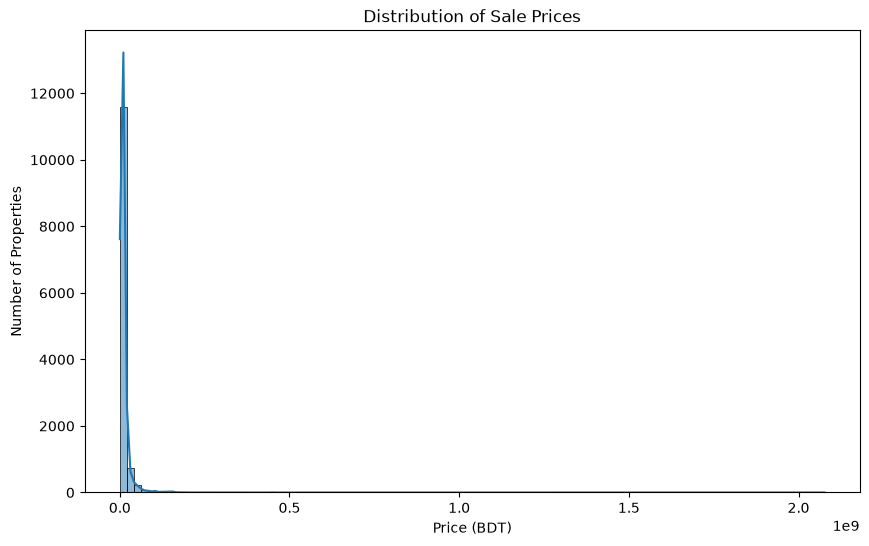

In [350]:
plt.figure(figsize=(10, 6))

sns.histplot(
    sale_clean["price"],
    bins=100,
    kde=True
)

plt.title("Distribution of Sale Prices")
plt.xlabel("Price (BDT)")
plt.ylabel("Number of Properties")

plt.show()

This confirms what the summary statistics already showed: most properties are priced in a realistic, similar range (likely under ৳50 million), but a small number of remaining high-value properties stretch the x-axis all the way to ৳2 billion. Because of this, the histogram looks almost like a single spike — the scale is being "stretched" by just a handful of expensive properties, making it hard to see the actual shape of the majority of the data.

This is a very common pattern with price/income-type data in real-world datasets, and it's a good, honest chart to include in an EDA report — but it's not very useful on its own for understanding the "typical" property price.

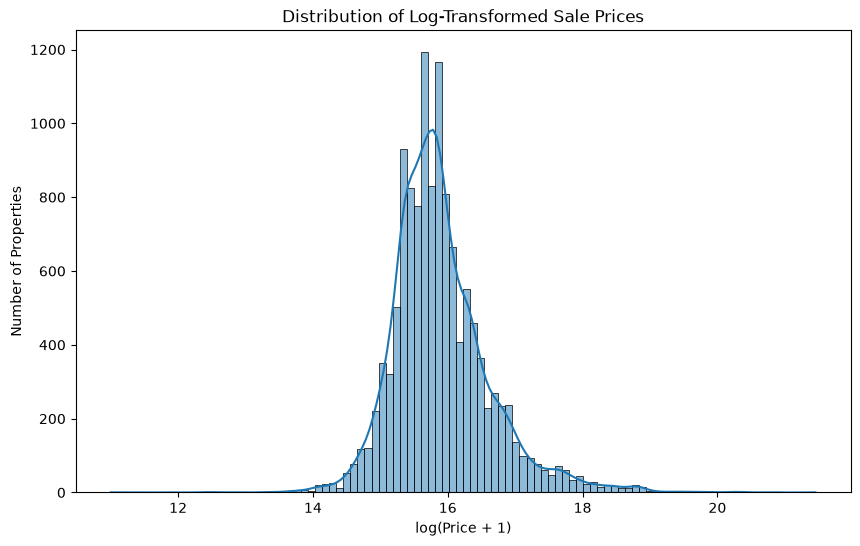

In [351]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(sale_clean["price"]),
    bins=100,
    kde=True
)

plt.title("Distribution of Log-Transformed Sale Prices")
plt.xlabel("log(Price + 1)")
plt.ylabel("Number of Properties")

plt.show()

After the log transformation, the distribution now looks much closer to a normal (bell-shaped) curve, with most values concentrated between log values 14–17 (roughly ৳1.2 million to ৳24 million in original price). This is a huge improvement over the raw price chart, where everything was squeezed into one spike due to a few extreme values.

There's a slight right skew still visible — a small tail extending toward 18–20 — meaning a few higher-priced properties still exist, but they're no longer distorting the entire chart the way they did before.

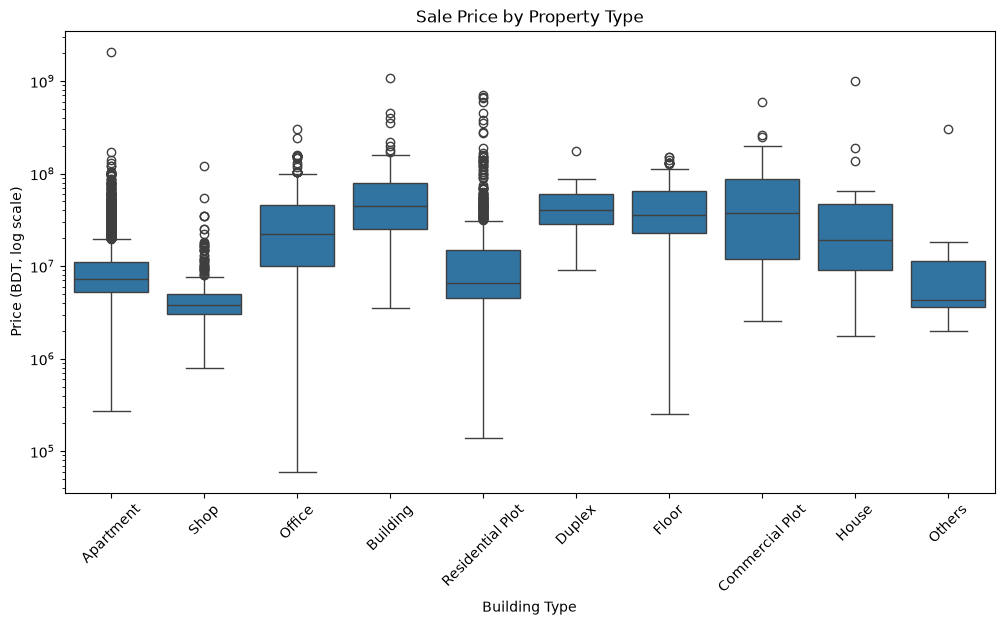

In [352]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=sale_clean,
    x="building_type",
    y="price"
)

plt.yscale("log")

plt.xticks(rotation=45)

plt.title("Sale Price by Property Type")
plt.xlabel("Building Type")
plt.ylabel("Price (BDT, log scale)")

plt.show()

Property type has a clear impact on price — smaller/simpler property types like Apartment, Shop, and Others tend to be cheaper, while larger property types like Building, Commercial Plot, and Office tend to be more expensive. This makes intuitive sense, since these types usually involve bigger spaces or commercial value.

The log scale was a good choice here — it makes it possible to compare all categories fairly, even though Residential Plot and Apartment still show many outlier points above their main box, meaning a few unusually expensive listings still exist within each category (even after your earlier cleaning).

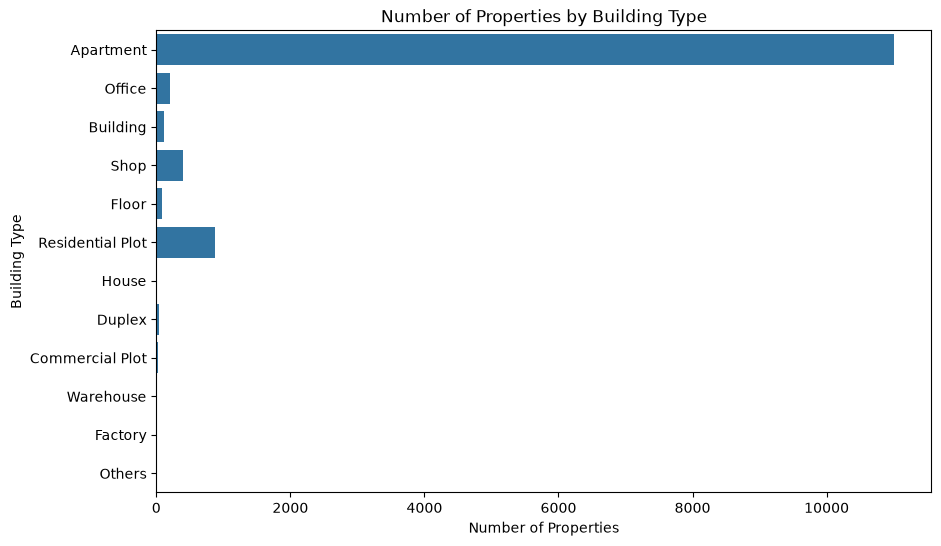

In [353]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=sale_clean,
    y="building_type",
    order=df["building_type"].value_counts().index
)

plt.title("Number of Properties by Building Type")
plt.xlabel("Number of Properties")
plt.ylabel("Building Type")

plt.show()

Even within the Sale dataset, Apartment still completely dominates, making up roughly 85% of all listings. Residential Plot is a distant second, and every other category is quite small in comparison. This confirms the same class imbalance seen earlier — it's not just a full-dataset issue, it carries over into the Sale-only data too.

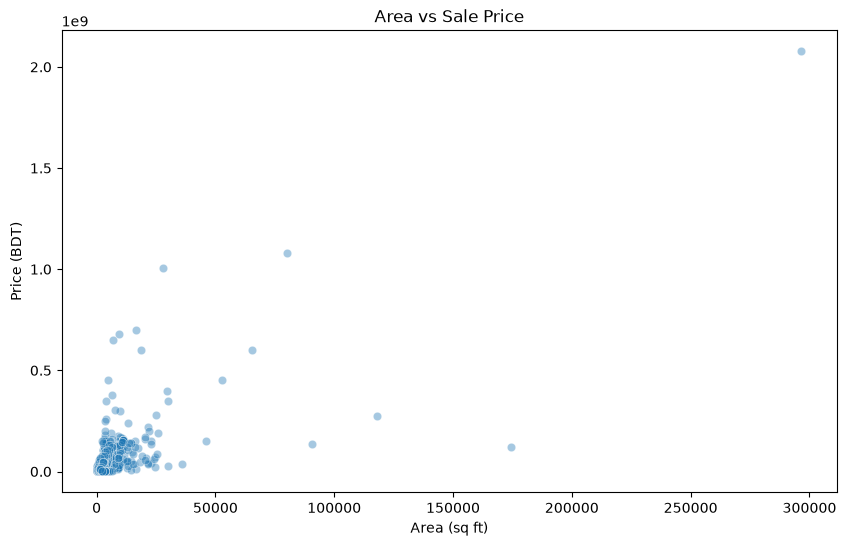

In [354]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sale_clean,
    x="area",
    y="price",
    alpha=0.4
)

plt.xlabel("Area (sq ft)")
plt.ylabel("Price (BDT)")
plt.title("Area vs Sale Price")

plt.show()

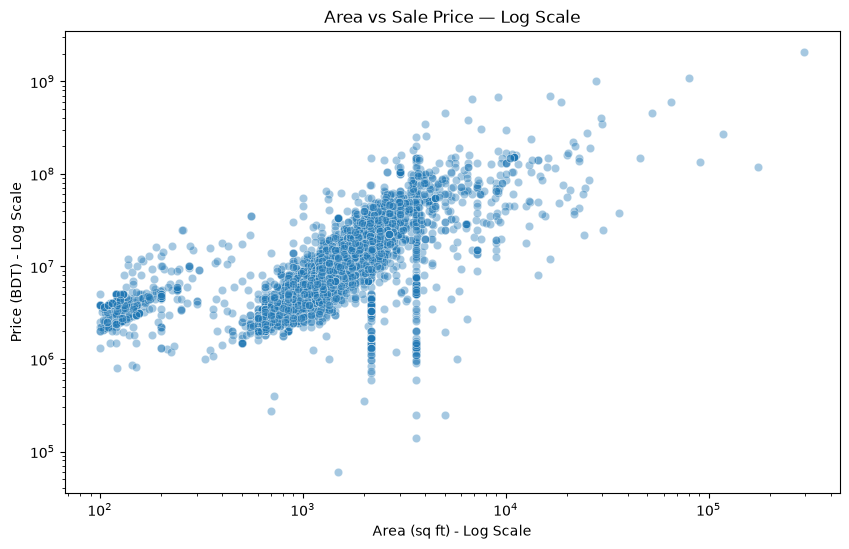

In [355]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sale_clean,
    x="area",
    y="price",
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Area (sq ft) - Log Scale")
plt.ylabel("Price (BDT) - Log Scale")
plt.title("Area vs Sale Price — Log Scale")

plt.show()

1. Overall positive relationship — as area increases, price also tends to increase. This makes intuitive sense: bigger properties generally cost more. The upward diagonal pattern in the point cloud confirms this trend.
2. Dense cluster in the middle — most listings fall between area ~1,000–4,000 sqft and price ~৳3M–৳100M, forming a thick, dense band. This represents the "typical" property in the dataset (mostly apartments).
3. Wide price variation at similar area — for properties around 2,000–3,000 sqft, prices range anywhere from ~৳1M to ~৳200M. This spread suggests other factors besides area (like location, building type, or amenities) also strongly influence price.
4. A few remaining low-price outliers — some points near the bottom (prices around ৳100K–1M for mid-sized areas) still look unusually cheap and may be worth a closer look, even after cleaning.
5. Large-area properties (right side) — points beyond 10,000 sqft are mostly Residential Plot or Building types (based on earlier analysis) and generally follow the expected upward price trend, though a bit more scattered.

In [356]:
city_price = (
    sale_clean.groupby("city")["price"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

city_price

,count,median,mean
city,,,
Habiganj,1,11898000.0,1.189800e+07
Chittagong,4,7500000.0,1.037500e+07
Dhaka,9916,7500000.0,1.269341e+07
Chattogram,2110,6800000.0,1.033532e+07
Narayanganj,11,5950000.0,8.217964e+06
Bandarban,1,5812800.0,5.812800e+06
Rangpur,1,5320000.0,5.320000e+06
Sylhet,15,4800000.0,9.431280e+06
Chandpur,3,4760000.0,4.876667e+06


1. Dhaka dominates the dataset — with 9,916 listings, it makes up the vast majority of the Sale dataset (roughly 77%). This matches the earlier finding that most data is concentrated in Dhaka.
2. Habiganj has the highest median price (৳11.9M), but this is based on just 1 listing — so it's not a reliable representation of that city's real estate market. The same issue applies to several other cities (Chittagong, Bandarban, Rangpur, Kishoreganj, Narsingdi, Jashore, Barguna, Sherpur) — all have only 1–4 listings, making their median/mean values statistically unreliable.
3. Dhaka and Chattogram are the only cities with a large, reliable sample size (9,916 and 2,110 listings respectively). Their median prices (৳7.5M and ৳6.8M) can be trusted as genuinely representative.
4. Mean is often higher than median across most cities (e.g., Dhaka: mean ৳12.7M vs median ৳7.5M), confirming that even after cleaning, price data is still right-skewed — a few higher-priced listings are pulling the average up compared to the "typical" (median) listing.
5. Narayanganj City has a notably large mean-median gap (median ৳4.57M vs mean ৳6.04M) despite having a decent sample size (440 listings) — this suggests a meaningful number of higher-priced outlier listings within that city specifically.

In [357]:
locality_stats = (
    sale_clean.groupby('locality')['price']
    .agg(['count', 'median'])
    .sort_values('count', ascending=False)
)

In [358]:
locality_stats.sort_values(
    "median",
    ascending=False
).head(20)

,count,median
locality,,
Sreepur,1,110000000.0
Banglamotors,2,85000000.0
Gulshan 2,23,79000000.0
Zindabazar,1,60000000.0
Kamrangirchar,1,48400000.0
Gulshan,52,47000000.0
DOHS Banani,2,45479000.0
Banani Dohs,8,40500000.0
Gulshan 1,20,39750000.0


In [359]:
bedroom_stats = (
    sale_clean[sale_clean["num_bed_rooms"] > 0]
    .groupby("num_bed_rooms")["price"]
    .agg(["count", "median"])
)

bedroom_stats

,count,median
num_bed_rooms,,
1.0,26,3400000.0
2.0,1814,4200000.0
3.0,8172,7500075.0
4.0,957,16000000.0
5.0,53,21000000.0
6.0,30,26250000.0
7.0,28,29000000.0
8.0,5,10500000.0
10.0,2,65012500.0


For 1 to 7 bedrooms, the pattern is exactly what you'd expect — price increases steadily as bedroom count goes up, and these categories have enough listings (26 to 8,172) to be considered reliable.

However, beyond 7 bedrooms, the pattern completely breaks down. For example:

- 8 bedrooms → median ৳10.5M (lower than 7 bedrooms!)
- 29 bedrooms → median ৳150M
- 30 bedrooms → median only ৳13.5M
- 56 bedrooms → median ৳208.5M (highest in the whole table)
- 94 bedrooms → median only ৳37M

This confirms your earlier observation — there is no reliable relationship between bedroom count and price once you go beyond 7 bedrooms, because each of these groups has only 1–9 listings, which is too small a sample to represent any real pattern. These jumps up and down are essentially random noise, not a genuine trend.

In [360]:
bathroom_stats = (
    sale_clean[sale_clean["num_bath_rooms"] > 0]
    .groupby("num_bath_rooms")["price"]
    .agg(["count", "median"])
)

bathroom_stats

,count,median
num_bath_rooms,,
1.0,36,3300000.0
2.0,1784,4725000.0
3.0,3490,8000000.0
4.0,826,13432000.0
5.0,131,23000000.0
6.0,28,24500000.0
7.0,4,34000000.0
8.0,10,29000000.0
9.0,2,42512500.0


Unlike bedrooms, bathrooms show a much clearer, more consistent pattern with price — as the number of bathrooms increases, the median price generally increases too, in a fairly steady, logical progression from 1 to 10 bathrooms. This makes sense, since more bathrooms usually means a larger, more premium property.

There's a small dip at 8 bathrooms (৳29M, lower than the 7-bathroom median of ৳34M) — but this is likely just due to the very small sample size (only 4 and 10 listings respectively), rather than a real trend.

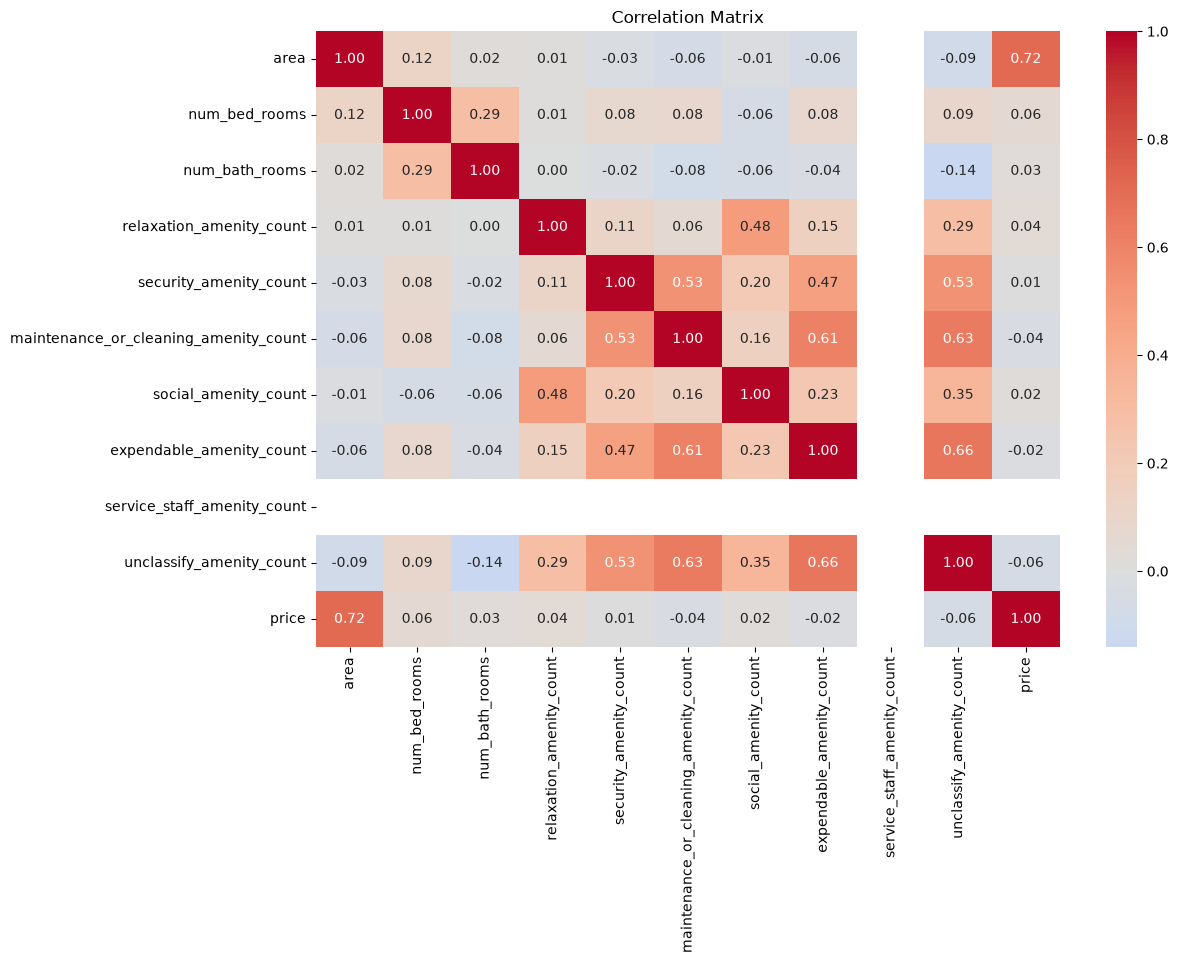

In [361]:
numeric_cols = [
    "area",
    "num_bed_rooms",
    "num_bath_rooms",
    "relaxation_amenity_count",
    "security_amenity_count",
    "maintenance_or_cleaning_amenity_count",
    "social_amenity_count",
    "expendable_amenity_count",
    "service_staff_amenity_count",
    "unclassify_amenity_count",
    "price"
]

corr = sale_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

1. Area and price now show a strong correlation (0.72) — a big change from the earlier matrix, where it was nearly 0.00. This strongly confirms that the log transformation fixed the issue — the relationship between area and price was always there, it just wasn't linear, so the original correlation couldn't detect it. Now it clearly shows up as one of the strongest relationships in the whole dataset.
2. Bedrooms and bathrooms still show weak correlation with price (0.06 and 0.03) — consistent with your earlier finding that these features are unreliable predictors, especially due to the extreme outlier bedroom/bathroom counts you investigated earlier.
3. service_staff_amenity_count row/column is completely empty — this usually happens when a column has almost no variation (e.g., nearly all values are 0), making correlation impossible to calculate (shows as blank/NaN). This matches your earlier .describe() output, where service_staff_amenity_count had a very low mean (~0.0002) — meaning almost every listing has 0 for this feature.
4. Amenity columns remain strongly correlated with each other (similar pattern to before) — confirming that properties with more amenities tend to have several types together, not just one.

In [362]:
log_df = sale_clean[["area", "price"]].copy()

log_df["area"] = np.log1p(log_df["area"])
log_df["price"] = np.log1p(log_df["price"])

log_df.corr()

,area,price
area,1.000000,0.650936
price,0.650936,1.000000


In [363]:
drop_columns = [
    "image_url",
    "property_description",
    "property_overview",
    "property_url",
    "id",
    "purpose",
    "address",
    "price_per_sqft"
]

model_df = sale_clean.drop(columns=drop_columns, errors='ignore').copy()

In [364]:
model_df.head()

,area,building_type,building_nature,num_bath_rooms,num_bed_rooms,price,city,locality,relaxation_amenity_count,security_amenity_count,maintenance_or_cleaning_amenity_count,social_amenity_count,expendable_amenity_count,service_staff_amenity_count,unclassify_amenity_count,division,zone
0,1185.0,Apartment,Residential,0.0,3.0,6100000.0,Dhaka,Khilgaon,0,1,2,0,2,0,3,Dhaka,Khilgaon
1,2464.0,Apartment,Residential,4.0,3.0,28900000.0,Dhaka,Dhanmondi,0,2,0,0,3,0,4,Dhaka,Dhanmondi
2,1140.0,Apartment,Residential,0.0,3.0,7500000.0,Dhaka,Mirpur,0,2,2,0,2,0,4,Dhaka,Mirpur
3,1920.0,Apartment,Residential,3.0,3.0,20000000.0,Dhaka,Bashundhara R-A,0,1,2,0,3,0,3,Dhaka,Bashundhara R/A
4,1445.0,Apartment,Residential,3.0,3.0,10800000.0,Dhaka,Banasree,0,0,2,0,1,0,4,Dhaka,Khilgaon


In [366]:
model_df.to_csv('../dataset/processed/processed_data.csv')